### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from dateutil import parser
from sklearn.preprocessing import MinMaxScaler

### Load Datasets

In [2]:
# primary dataset
file_path = 'gs://data-analyst-wage-trends/prim/gsearch_jobs.csv'
data_jobs = pd.read_csv(file_path, encoding='latin-1')

# supplementary dataset
file_path2 = 'gs://data-analyst-wage-trends/suppl-1/cost_of_living_us.csv'
cost_living = pd.read_csv(file_path2, encoding='latin-1')

### Feature Selection

In [3]:
# selecting columns
data_jobs = data_jobs[['title', 'company_name', 'location', 'salary_hourly', 'salary_yearly', 'schedule_type', 'work_from_home', 'date_time', 'description_tokens']]

# rename column
data_jobs.rename(columns={'description_tokens': 'skillset'}, inplace=True)
data_jobs.head(5)

,title,company_name,location,salary_hourly,salary_yearly,schedule_type,work_from_home,date_time,skillset
0,Data Analyst,Meta,Anywhere,NaN,122000.0,Full-time,True,2023-08-04 03:00:13.797776,"['tableau', 'r', 'python', 'sql']"
1,Data Analyst,ATC,United States,NaN,NaN,Full-time,NaN,2023-08-04 03:00:13.797776,[]
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",NaN,NaN,Full-time,NaN,2023-08-04 03:00:13.797776,['sql']
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,20.0,NaN,Contractor,True,2023-08-04 03:00:13.797776,"['powerpoint', 'excel', 'power_bi']"
4,Data Analyst | Workforce Management,Krispy Kreme,United States,NaN,100000.0,Contractor,NaN,2023-08-04 03:00:13.797776,"['powerpoint', 'excel', 'outlook', 'word']"


In [4]:
# selecting columns
cost_living = cost_living[['state','total_cost','family_member_count','areaname']]
cost_living.head(5)

,state,total_cost,family_member_count,areaname
0,AL,39254.0532,1p0c,"Montgomery, AL MSA"
1,AL,57194.3256,1p1c,"Montgomery, AL MSA"
2,AL,76141.0308,1p2c,"Montgomery, AL MSA"
3,AL,94203.5328,1p3c,"Montgomery, AL MSA"
4,AL,100823.5200,1p4c,"Montgomery, AL MSA"


### Creating New Columns

In [5]:
data_jobs['state'] = data_jobs['location'].str.extract(r',\s*([A-Z]{2})')

In [6]:
data_jobs[['location', 'state']].head(10)

,location,state
0,Anywhere,NaN
1,United States,NaN
2,"Olathe, KS",KS
3,Anywhere,NaN
4,United States,NaN
5,"Wichita, KS",KS
6,Anywhere,NaN
7,United States,NaN
8,Anywhere,NaN
9,"Oklahoma City, OK",OK


### Transforming Features

In [7]:
# check current data types
data_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           61953 non-null  object 
 1   company_name    61953 non-null  object 
 2   location        61916 non-null  object 
 3   salary_hourly   5900 non-null   float64
 4   salary_yearly   4069 non-null   float64
 5   schedule_type   61707 non-null  object 
 6   work_from_home  27980 non-null  object 
 7   date_time       61953 non-null  object 
 8   skillset        61953 non-null  object 
 9   state           17943 non-null  object 
dtypes: float64(2), object(8)
memory usage: 4.7+ MB


The only feature needing to be transformed in the data_jobs dataset is the date_time feature. We have to tranform it to a date time data type in order to perform proper aggregations later.

In [8]:
data_jobs['date_time'] = data_jobs['date_time'].apply(parser.parse)

In [9]:
data_jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   title           61953 non-null  object        
 1   company_name    61953 non-null  object        
 2   location        61916 non-null  object        
 3   salary_hourly   5900 non-null   float64       
 4   salary_yearly   4069 non-null   float64       
 5   schedule_type   61707 non-null  object        
 6   work_from_home  27980 non-null  object        
 7   date_time       61953 non-null  datetime64[ns]
 8   skillset        61953 non-null  object        
 9   state           17943 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 4.7+ MB


In [10]:
# check current data types
cost_living.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31430 entries, 0 to 31429
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                31430 non-null  object 
 1   total_cost           31430 non-null  float64
 2   family_member_count  31430 non-null  object 
 3   areaname             31430 non-null  object 
dtypes: float64(1), object(3)
memory usage: 982.3+ KB


The cost_living dataset has no variables that need to be transformed.

### Index the Data on Time Feature

In [11]:
data_jobs = data_jobs.set_index("date_time")

In [12]:
data_jobs.sample(3)

,title,company_name,location,salary_hourly,salary_yearly,schedule_type,work_from_home,skillset,state
date_time,,,,,,,,,
2023-07-22 03:00:27.981063,Data clean for sales territory data,Upwork,Anywhere,NaN,NaN,Contractor,True,[],NaN
2025-01-22 04:00:11.269581,Business Analyst Intern,Mike Maroone Automotive,"Boulder, CO",19.0,NaN,Internship,NaN,['excel'],CO
2022-12-26 04:00:10.996841,Senior Data Analyst,H&R Block,"Kansas City, MO",NaN,NaN,Full-time,NaN,"['power_bi', 'r']",MO


Since state can be utilized as a merging key without being set as the index, we decided not to re-index the cost_living dataset. The flexibility for grouping, filtering, and reshaping operations is maintained without additional structural complexity by maintaining state as a standard column. A RangeIndex is adequate for the analysis because the dataset does not use hierarchical indexing or time-series slicing.

### Handling Missing Values


In [13]:
data_jobs.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61953 entries, 2023-08-04 03:00:13.797776 to 2023-01-25 04:00:26.521124
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           61953 non-null  object 
 1   company_name    61953 non-null  object 
 2   location        61916 non-null  object 
 3   salary_hourly   5900 non-null   float64
 4   salary_yearly   4069 non-null   float64
 5   schedule_type   61707 non-null  object 
 6   work_from_home  27980 non-null  object 
 7   skillset        61953 non-null  object 
 8   state           17943 non-null  object 
dtypes: float64(2), object(7)
memory usage: 4.7+ MB


There are NA values in the follow columns: location, salary_hourly, salary_yearly, schedule_type, work_from_home, and state.

In [14]:
data_jobs["work_from_home"] = data_jobs["work_from_home"].fillna(False)

/tmp/ipython-input-2306037442.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_jobs["work_from_home"] = data_jobs["work_from_home"].fillna(False)


Missing work_from_home values most likely mean that the job posting did not specifically state if the position was remote. To enable consistent analysis of remote versus non-remote roles without creating ambiguity, these NaN values should be filled with False, assuming that only job ads clearly marked as remote should be handled as such.

In [15]:
# Replace missing schedule_type values with "Unknown"
# so unreported job types are clearly labeled.
data_jobs["schedule_type"] = data_jobs["schedule_type"].fillna("Unknown")

In [16]:
# Replace missing state values with "Other"
# to label postings without a specific state.
data_jobs["state"] = data_jobs["state"].fillna("Other")

In [17]:
data_jobs = data_jobs.dropna(subset=['location'])

All remaining job posts can be assigned to a geographic category (such as state) by removing rows with missing locations. This is required for precise aggregation and merging with cost-of-living data. Because location is essential to the analysis, it is impossible to include rows without it in a meaningful way.

Mean after filling with 0: 3.8620238710511017
Median after filling with 0: 0.0


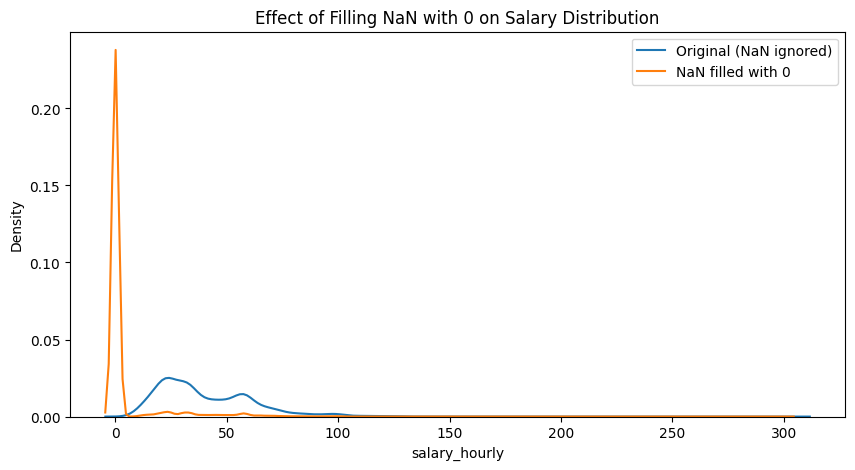

In [18]:
# testing if filling salary NA values with 0 is appropiate
salary_hourly_zero = data_jobs['salary_hourly'].fillna(0)

zero_mean = salary_hourly_zero.mean()
zero_median = salary_hourly_zero.median()

print("Mean after filling with 0:", zero_mean)
print("Median after filling with 0:", zero_median)

plt.figure(figsize=(10,5))

sns.kdeplot(data_jobs['salary_hourly'].dropna(), label='Original (NaN ignored)')
sns.kdeplot(salary_hourly_zero, label='NaN filled with 0')

plt.legend()
plt.title("Effect of Filling NaN with 0 on Salary Distribution")
plt.show()

Filling in missing salary numbers with 0 distorts both the mean and median, resulting in the median dropping to 0 and the mean collapsing to around 3.86. Zero is also not a legitimate wage; rather, it is missing data, as our objective is to examine real compensation trends. By adding these fictitious zeros, the salary distribution is essentially distorted, and any further study is biased.

In [19]:
data_jobs = data_jobs.dropna(subset=['salary_hourly', 'salary_yearly'], how='all')

Because our analysis revolves around salary progression, it is better that rows with missing salary_hourly and salary_yearly are dropped. This preserves postings that report wage in either format while avoiding the inclusion of observations that lack useful pay data.

In [20]:
data_jobs['salary_yearly'] = (data_jobs['salary_yearly'].fillna(data_jobs['salary_hourly'] * 2080))

In [21]:
# drop salary_hourly column
data_jobs = data_jobs.drop(columns=['salary_hourly'])

Hourly wages were converted to annual equivalents to estimate missing yearly salaries (assuming 2,080 working hours per year). This allows for uniform comparison and aggregation across job advertisements by standardizing salary into a single annual measure.

In [22]:
data_jobs.head(3)

,title,company_name,location,salary_yearly,schedule_type,work_from_home,skillset,state
date_time,,,,,,,,
2023-08-04 03:00:13.797776,Data Analyst,Meta,Anywhere,122000.0,Full-time,True,"['tableau', 'r', 'python', 'sql']",Other
2023-08-04 03:00:13.797776,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,41600.0,Contractor,True,"['powerpoint', 'excel', 'power_bi']",Other
2023-08-04 03:00:13.797776,Data Analyst | Workforce Management,Krispy Kreme,United States,100000.0,Contractor,False,"['powerpoint', 'excel', 'outlook', 'word']",Other


In [23]:
data_jobs.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9963 entries, 2023-08-04 03:00:13.797776 to 2023-01-25 04:00:26.521124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           9963 non-null   object 
 1   company_name    9963 non-null   object 
 2   location        9963 non-null   object 
 3   salary_yearly   9963 non-null   float64
 4   schedule_type   9963 non-null   object 
 5   work_from_home  9963 non-null   bool   
 6   skillset        9963 non-null   object 
 7   state           9963 non-null   object 
dtypes: bool(1), float64(1), object(6)
memory usage: 632.4+ KB


There are now 9963 non null objects in each column, meaning all of the NA values have been taken care of.

### Data Smoothing

Smoothing should be used to make longer-term patterns simpler to understand and to lessen short-term month-to-month volatility in the median salary data. Temporary hiring trends, sample size variations, or reporting discrepancies might cause job postings to fluctuate, masking underlying market developments. Instead of responding to sporadic monthly spikes or troughs, using 3- and 6-month rolling median helps emphasize structural changes in compensation over time.

In [24]:
monthly_salary = (
    data_jobs['salary_yearly']
    .resample('M')
    .median()
)

/tmp/ipython-input-1128478978.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


In [25]:
# calculating 3 and 6 month rolling medians
monthly_salary_3ma = monthly_salary.rolling(window=3).median()
monthly_salary_6ma = monthly_salary.rolling(window=6).median()


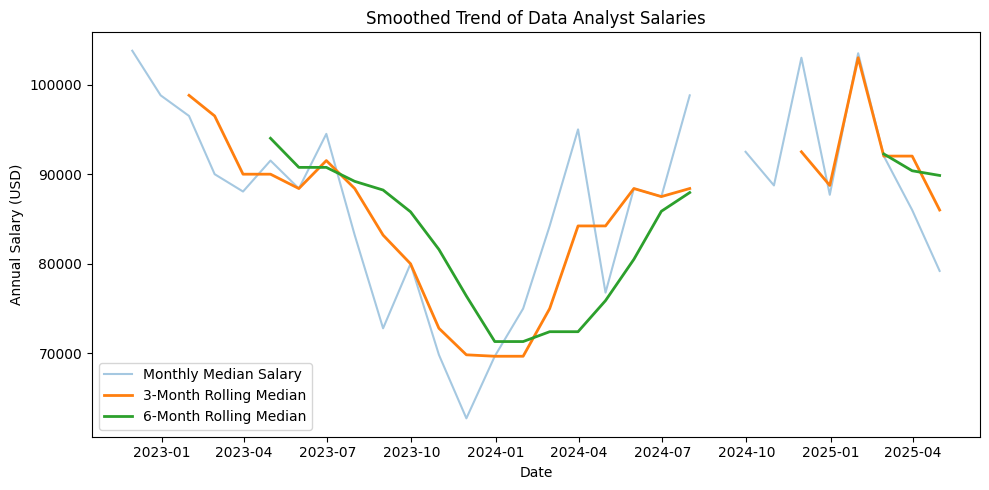

In [26]:
plt.figure(figsize=(10,5))

plt.plot(monthly_salary, label='Monthly Median Salary', alpha=0.4)
plt.plot(monthly_salary_3ma, label='3-Month Rolling Median', linewidth=2)
plt.plot(monthly_salary_6ma, label='6-Month Rolling Median', linewidth=2)

plt.title('Smoothed Trend of Data Analyst Salaries')
plt.ylabel('Annual Salary (USD)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


With notable month-to-month variations that probably reflect posting variability rather than actual market moves, the raw monthly median salary line is obviously noisy. By reducing this short-term volatility, rolling medians help to clarify and simplify the underlying pattern, which is the decline in late 2023 followed by the recovery in 2024.

### Aggregate Data

In [27]:
# Aggregate median annual salary by state to compare typical salary levels
# while reducing the influence of extreme outliers in salary data.
salary_by_state = data_jobs.groupby('state')['salary_yearly'].median()
salary_by_state.head(7)

,salary_yearly
state,
AR,100000.0
CA,90000.0
CO,87050.0
KS,96500.0
MO,57000.0
NE,95000.0
NJ,60299.2


In [28]:
# Aggregate median annual salary by state and month to analyze time trends
# while minimizing the effect of extreme salary outliers
salary_monthly_by_state = data_jobs.groupby(
    ['state', pd.Grouper(freq='ME')]
)['salary_yearly'].median()

salary_monthly_by_state.head(5)

state  date_time 
AR     2022-12-31    122500.0
       2023-01-31     96500.0
       2023-02-28     93250.0
       2023-03-31     87500.0
       2023-04-30     85690.0
Name: salary_yearly, dtype: float64

In [29]:
# Aggregate median total cost of living by state to obtain a representative
# living expense measure while reducing the influence of extreme values.
col_by_state = cost_living.groupby('state')['total_cost'].median()
col_by_state.head()

,total_cost
state,
AK,86130.7908
AL,73026.2868
AR,64790.3994
AZ,76835.3088
CA,89793.1464


### Truncate Range

Because the entire time range and geographic coverage are relevant to the study issue and contribute to maintaining the overall integrity of the trend, the dataset was not trimmed. Especially in time-series analysis, deleting portions of the data may cause bias or skew longitudinal patterns. Furthermore, no obvious structural discontinuities or extraneous areas were found that would support limiting the scope.

### Merge Datasets

In [30]:
# get rid of rows without a specific US state attached
data_jobs_state = data_jobs[~data_jobs['state'].isin(['Other'])]
salary_month_by_states_only = data_jobs_state.groupby(
    ['state', pd.Grouper(freq='ME')]
)['salary_yearly'].median()

# convert the multi-index salary series into a DataFrame
salary_monthly_by_state_df = salary_month_by_states_only.reset_index()

# convert COL series into a DataFrame
col_by_state_df = col_by_state.reset_index()

# merge on state
merged_monthly_salary = salary_monthly_by_state_df.merge(col_by_state_df, on='state', how='left')
merged_monthly_salary.sample(5)


,state,date_time,salary_yearly,total_cost
7,AR,2023-08-31,80000.0,64790.3994
104,OK,2024-01-31,42244.8,74993.8914
97,OK,2023-06-30,96500.0,74993.8914
22,CA,2022-12-31,107029.0,89793.1464
123,WY,2025-04-30,25740.0,90231.9024


### Save to GCS

In [32]:
merged_monthly_salary.to_parquet('gs://data-analyst-wage-trends/clean/merged_monthly_salaries.parquet')
data_jobs.to_parquet('gs://data-analyst-wage-trends/clean/data_jobs_cleaned.parquet')

In [36]:
merged_monthly_salary = pd.read_parquet('gs://data-analyst-wage-trends/clean/merged_monthly_salaries.parquet')
merged_monthly_salary.head()

,state,date_time,salary_yearly,total_cost
0,AR,2022-12-31,122500.0,64790.3994
1,AR,2023-01-31,96500.0,64790.3994
2,AR,2023-02-28,93250.0,64790.3994
3,AR,2023-03-31,87500.0,64790.3994
4,AR,2023-04-30,85690.0,64790.3994


In [35]:
data_jobs = pd.read_parquet('gs://data-analyst-wage-trends/clean/data_jobs_cleaned.parquet')
data_jobs.head()

,title,company_name,location,salary_yearly,schedule_type,work_from_home,skillset,state
date_time,,,,,,,,
2023-08-04 03:00:13.797776,Data Analyst,Meta,Anywhere,122000.0,Full-time,True,"['tableau', 'r', 'python', 'sql']",Other
2023-08-04 03:00:13.797776,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,41600.0,Contractor,True,"['powerpoint', 'excel', 'power_bi']",Other
2023-08-04 03:00:13.797776,Data Analyst | Workforce Management,Krispy Kreme,United States,100000.0,Contractor,False,"['powerpoint', 'excel', 'outlook', 'word']",Other
2023-08-04 03:00:19.724974,Senior Data Analyst,Aquent,Anywhere,119100.8,Unknown,True,['sql'],Other
2023-08-04 03:00:19.724974,Mid-level Claims Data Analyst,CIBA Insurance Services,United States,110000.0,Full-time,False,"['excel', 'mssql', 'ssrs', 'sql']",Other
